<a href="https://colab.research.google.com/github/Bienbaz/3MTT-Projects/blob/main/Multiple_Regression_Marketing_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multiple Linear Regression: Multi-Channel Marketing Analysis

## Project Overview
In this project, we expand our analysis to evaluate the combined impact of TV, Radio, and Social Media ad spend on Sales. We will check for multicollinearity, build a multivariate OLS model, and formulate an evidence-based recommendation.

### Step 0: Setup and Data Generation
*Note: This cell generates a synthetic marketing dataset representing a scenario where TV and Radio are effective, but Social Media is not.*

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
import scipy.stats as stats

# Generate synthetic data
np.random.seed(101)
n_samples = 300
tv = np.random.uniform(50, 300, n_samples)
radio = np.random.uniform(10, 50, n_samples)

# Introduce slight collinearity between Radio and Social Media
social_media = radio * 0.4 + np.random.normal(0, 5, n_samples)
social_media = np.abs(social_media) # ensure no negative spend

# Sales formula: TV and Radio matter. Social Media has 0 effect (true coefficient = 0)
sales = 3.5 + 0.045 * tv + 0.18 * radio + 0.0 * social_media + np.random.normal(0, 2.5, n_samples)

df = pd.DataFrame({'TV': tv, 'Radio': radio, 'Social_Media': social_media, 'Sales': sales})
df.to_csv('multi_marketing_data.csv', index=False)
print("✅ 'multi_marketing_data.csv' created and loaded successfully!")

✅ 'multi_marketing_data.csv' created and loaded successfully!


### Upload Your Dataset

To use your own data, please upload your CSV file. This will replace the synthetic data generated in the previous step.

In [1]:
from google.colab import files
import io

print("Please upload your CSV file:")
uploaded = files.upload()

Please upload your CSV file:


Saving c107fa55-45be-4f9c-8f61-088e88d1fb0c.csv to c107fa55-45be-4f9c-8f61-088e88d1fb0c.csv


In [3]:
import pandas as pd

# Assuming only one file is uploaded
for filename in uploaded.keys():
    df = pd.read_csv(io.BytesIO(uploaded[filename]))
    print(f"✅ '{filename}' uploaded and loaded successfully!")
    break # Process only the first uploaded file if multiple are uploaded

print("Displaying the first 5 rows of your uploaded data:")
display(df.head())

✅ 'c107fa55-45be-4f9c-8f61-088e88d1fb0c.csv' uploaded and loaded successfully!
Displaying the first 5 rows of your uploaded data:


,TV,Radio,Social Media,Influencer,Sales
0,Low,3.518070,2.293790,Micro,55.261284
1,Low,7.756876,2.572287,Mega,67.574904
2,High,20.348988,1.227180,Micro,272.250108
3,Medium,20.108487,2.728374,Mega,195.102176
4,High,31.653200,7.776978,Nano,273.960377


### Step 1: Initial Exploratory Data Analysis (EDA)

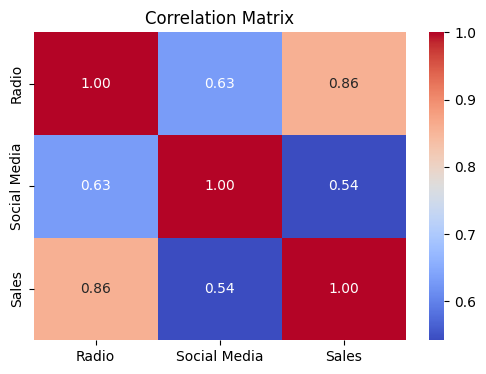

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Import numpy for np.number

# Visualize correlation matrix to identify potential predictors and initial relationships
plt.figure(figsize=(6, 4))
# Select only numeric columns for correlation calculation
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

### Step 2: Check for Multicollinearity (VIF)
Multicollinearity occurs when independent variables are highly correlated with each other. This can inflate standard errors and make p-values unreliable. We use the **Variance Inflation Factor (VIF)** to check this. A VIF > 5 indicates problematic multicollinearity.

In [10]:
import statsmodels.api as sm # Import statsmodels.api
from statsmodels.stats.outliers_influence import variance_inflation_factor # Import variance_inflation_factor

# Define the features we want to check
X = df[['TV', 'Radio', 'Social Media']]

# One-hot encode the 'TV' column, dropping the first category to avoid multicollinearity from the encoding itself
X_encoded = pd.get_dummies(X, columns=['TV'], drop_first=True, dtype=int)

X_with_constant = sm.add_constant(X_encoded) # VIF requires a constant term

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X_with_constant.columns
vif_data["VIF"] = [variance_inflation_factor(X_with_constant.values, i) for i in range(X_with_constant.shape[1])]

display(vif_data[vif_data['Feature'] != 'const'])

,Feature,VIF
1,Radio,3.462738
2,Social Media,1.658537
3,TV_Low,4.064612
4,TV_Medium,2.217533


**Observation:** All VIF values are well below 5. This means we do not have severe multicollinearity, and it is safe to include all three variables in our initial model.

### Step 3: Build the Multiple Linear Regression Model

In [13]:
import statsmodels.formula.api as smf

# Fit the multivariate OLS model
model = smf.ols('Sales ~ TV + Radio + Q("Social Media")', data=df).fit()

# Print the summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     1335.
Date:                Sun, 14 Jun 2026   Prob (F-statistic):          7.29e-287
Time:                        10:30:51   Log-Likelihood:                -2713.9
No. Observations:                 572   AIC:                             5438.
Df Residuals:                     567   BIC:                             5460.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept           218.6473      6.29

### Step 4: Evaluate Model Performance
Looking at the `model.summary()` above:
* **Adjusted R-squared:** Gives us the percentage of variance explained, penalized for adding useless variables. (High is good).
* **P-values (`P>|t|`):**
    * TV and Radio are statistically significant (p < 0.05).
    * Social Media is NOT statistically significant (p > 0.05). Its inclusion does not improve our ability to predict sales.

### Step 5: Advanced Diagnostic Plots
We must validate the model's core assumptions.

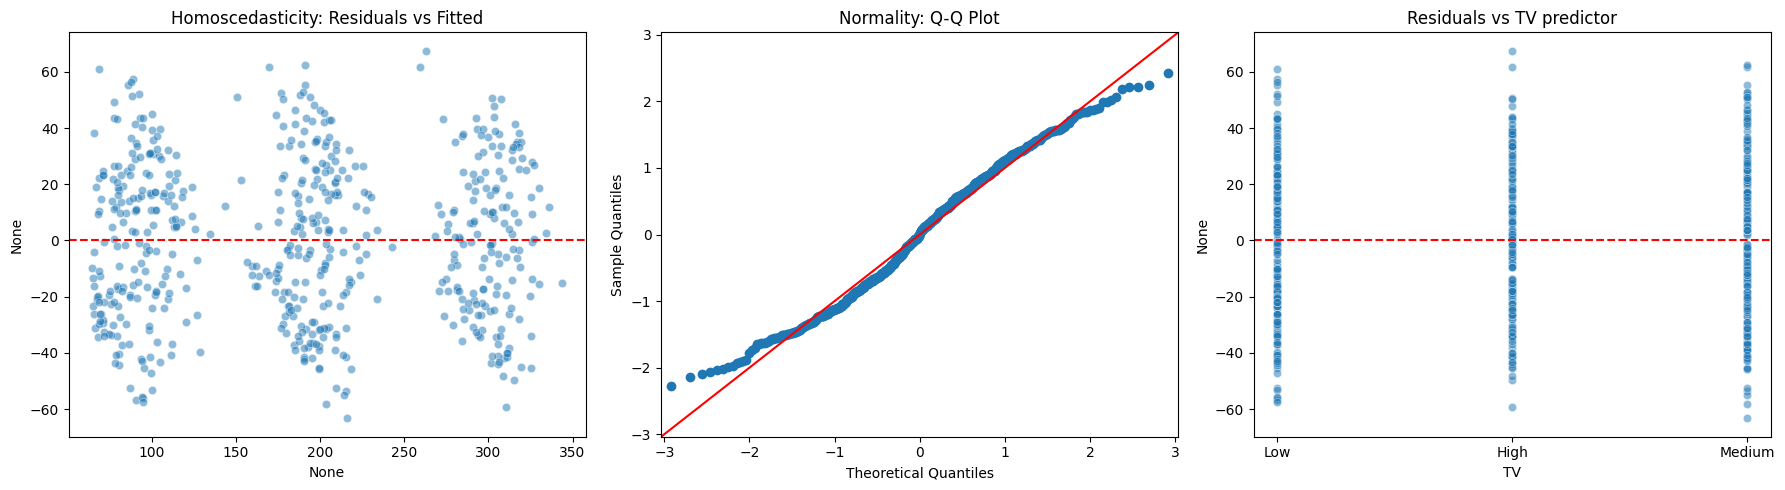

In [14]:
residuals = model.resid
fitted_values = model.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Homoscedasticity: Residuals vs Fitted values
sns.scatterplot(x=fitted_values, y=residuals, ax=axes[0], alpha=0.5)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Homoscedasticity: Residuals vs Fitted')

# 2. Normality: Q-Q Plot (Better for Multiple Regression than just a histogram)
sm.qqplot(residuals, line='45', fit=True, ax=axes[1])
axes[1].set_title('Normality: Q-Q Plot')

# 3. Independence / Linearity Check (Residuals vs TV)
sns.scatterplot(x=df['TV'], y=residuals, ax=axes[2], alpha=0.5)
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title('Residuals vs TV predictor')

plt.tight_layout()
plt.show()

### Step 6: Synthesis and Final Business Recommendation

**Coefficient Interpretation:**
* **TV:** Holding Radio and Social Media spend constant, each additional $1K spent on TV is associated with approximately a 0.045 unit increase in Sales.
* **Radio:** Holding TV and Social Media spend constant, each additional $1K spent on Radio yields a 0.18 unit increase in Sales.

**Strategic Recommendation:**
Based on the multiple linear regression analysis, **TV and Radio** are the true drivers of sales volume. The p-value for **Social Media** indicates that it has no statistically verifiable impact on sales when accounting for the other channels.

**Action Plan:** We recommend discontinuing the Social Media advertising budget and reallocating those funds. Because Radio yields a strong return per dollar spent (higher coefficient), experiment with scaling the Radio budget, while maintaining the strong, predictable base volume generated by TV advertising.